In [1]:
!pip install plotly

In [2]:
!pip install "anywidget>=0.9.13"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 2.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 2.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.3/477.3 kB 7.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 8.1 MB/s eta 0:00:0000:0100:01


In [3]:
!pip install -U kaleido

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.4 MB/s eta 0:00:00:00:0100:01


In [4]:
!pip install anndata==0.8.0

In [1]:
def gexpnorm(adata, gene_dict,level, gl, fin_name):
    present = [g for g in gl if g in gene_dict]
    missing = [g for g in gl if g not in gene_dict]
    gi = [gene_dict[i] for i in present]
    exp = adata[:,gi].X.A
    expr = pd.DataFrame(exp,columns = present, index = adata.obs_names)
    expr["cell_type"] = adata.obs[level].values
    mean_expr = expr.groupby("cell_type").mean()
    frac_expr = expr.groupby("cell_type").apply(
    lambda x: (x > 0).mean())
    mean_expr_norm = (mean_expr - mean_expr.min()) / (
    mean_expr.max() - mean_expr.min())
    for g in missing:
        mean_expr_norm[g] = 0
        frac_expr[g] = 0
    mean_expr_norm = mean_expr_norm[gl]
    frac_expr = frac_expr[gl]
    mean_expr_norm.columns = fin_name
    frac_expr.columns = fin_name
    return(mean_expr_norm, frac_expr)

In [2]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [110]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv
import plotly.express as px
from sklearn.manifold import TSNE
import matplotlib.cm as cm
from matplotlib import colors

In [4]:
sm = load_samap('Subclustering/PVH/sm_hypoorgs_PVH_02182026.pkl')

In [5]:
fn = 'Subclustering/PVH/SAM_MO_soupx_plus5_cleaned_PVH_03122025.h5ad'
sam_mo = SAM()
sam_mo.load_data(fn)
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i
gene_dict_mo['NaN'] = 'NaN'

In [6]:
fn = 'Subclustering/PVH/SAM_CJ_joined_v2_cleaned_03122025_PVH.h5ad'
sam_cj = SAM()
sam_cj.load_data(fn)
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i
gene_dict_cj['NaN'] = 'NaN'

In [7]:
fn = 'Subclustering/PVH/SAM_AC_ncbi_soupx_cleaned_PVH_03122025.h5ad'
sam_ac = SAM()
sam_ac.load_data(fn)
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i
gene_dict_ac['NaN'] = 'NaN'

In [8]:
fn = 'Subclustering/PVH/SAM_XT_joined_Slc17a6_cleaned_03122205_PVH.h5ad'
sam_xt = SAM()
sam_xt.load_data(fn)
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i
gene_dict_xt['NaN'] = 'NaN'

In [9]:
fn = 'Subclustering/PVH/SAM_DR_ncbi_PVH_03142025.h5ad'
sam_dr = SAM()
sam_dr.load_data(fn)
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i
gene_dict_dr['NaN'] = 'NaN'

In [10]:
sam_mg = SAM()
sam_mg.load_data('Subclustering/PVH/SAM_Allen_Institute_PVH.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i
gene_dict_mg['NaN'] = 'NaN'

In [11]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'eq_clusters', 'eq_supertype',
       'cluster_names', 'cluster_names_v1', 'eq_supertype_v2', 'test',
       'clusters_v2'],
      dtype='object')

In [13]:
orthogroups = pd.read_csv('Vert_emapper_allorgs_07032026.tsv', delimiter='\t',index_col = 'Unnamed: 0')
mg_mapping_ortho = orthogroup_mapper(orthogroups, 'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups, 'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups, 'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups, 'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups, 'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [14]:
orthogroups.loc[mg_mapping_ortho['Agtr1a'],:]

MM                            Agtr1b,Agtr1a
MO    ENSMOCG00000007296,ENSMOCG00000019499
CJ                                    AGTR1
AC                                      NaN
XT                                    agtr1
DR                            agtr1a,agtr1b
Name: 48UV9@7742, dtype: object

In [151]:
m = pd.read_csv('BLASTMAPPING/maps/active_maps/hypo_proj/mgac/mg_to_ac.txt',delimiter = '\t',header = None)

In [153]:
m[m[0] == 'Ucn3']

,0,1,2,3,4,5,6,7,8,9,10,11
600315,Ucn3,ucn3,48.571,70,36,0,285,494,400,609,3.180000e-25,90.0


In [34]:
sam_mg.adata.obs['eq_supertype_v2'] = sam_mg.adata.obs['eq_supertype']

In [154]:
mg_genes = ['Avp','Oxt','Nkx2-2','Ucn3','Sst','Crh','Ucn','Trh',]
mo_genes = ['Avp','Oxt','Nkx2-2','UCN3','Sst','Crh','UCN','Trh',]
cj_genes = ['ENSCJPG00005007573','ENSCJPG00005007570','ENSCJPG00005006711','UCN3','SST','CRH','UCN','TRH']
ac_genes = ['LOC134299523','LOC134299526','nkx2-2','ucn3','sst','crh','trh']
xt_genes = ['avp','oxt','nkx2-2','ucn3','sst.1','ENSXETG00000035344','UCN','trh']
dr_genes = ['avp','oxt','nkx2.2a','ucn3l','sst1.1','crhb','uts1','trh']

mg_genes.reverse()
mo_genes.reverse()
cj_genes.reverse()
ac_genes.reverse()
xt_genes.reverse()
dr_genes.reverse()

In [155]:
mean_expr_norm_mg, frac_mg = gexpnorm(sam_mg.adata,gene_dict_mg,'eq_supertype_v2',
                             mg_genes,
                            mg_genes)
mean_expr_norm_mo, frac_mo = gexpnorm(sam_mo.adata,gene_dict_mo,'eq_supertype_v2',
                             mo_genes,
                            mg_genes)
mean_expr_norm_cj, frac_cj = gexpnorm(sam_cj.adata,gene_dict_cj,'eq_supertype_v2',
                             cj_genes,
                            mg_genes)
mean_expr_norm_ac, frac_ac = gexpnorm(sam_ac.adata,gene_dict_ac,'eq_supertype_v2',
                             ac_genes,
                            ['Trh','Crh','Sst','Ucn3','Nkx2-2','Oxt','Avp'])
mean_expr_norm_xt, frac_xt = gexpnorm(sam_xt.adata,gene_dict_xt,'eq_supertype_v2',
                             xt_genes,
                            mg_genes)
mean_expr_norm_dr, frac_dr = gexpnorm(sam_dr.adata,gene_dict_dr,'eq_supertype_v2',
                             dr_genes,
                            mg_genes)

In [36]:
test = [['Avp','Crh','Oxt','Sst','Trh','Ucn3','Ucn','Nkx2-2'],
['Avp','Crh','Oxt','Sst','Trh','UCN3','UCN','Nkx2-2'],
['ENSCJPG00005007573','CRH','ENSCJPG00005007570','SST','TRH','UCN3','UCN','ENSCJPG00005006711'],
['LOC134299523','crh','LOC134299526','sst','trh','ucn3',np.nan,'nkx2-2'],
['avp','ENSXETG00000035344','oxt','sst.1','trh','ucn3','UCN','nkx2-2'],
['avp','crhb','oxt','sst1.1','trh','ucn3l','uts1','nkx2.2a']]

In [37]:
df = pd.DataFrame(test,index = ['Mouse names','Vole names','Quail names','Anole names','Xenopus names','Zebrafish names']).T

In [38]:
df.to_csv('Genes_PVH_mapping_allorgs_Fig4B_07062026.csv')

In [156]:
df = pd.DataFrame(columns = ['celltype','gene','avg exp','frac'])

In [157]:
mgl = []
for ct in mean_expr_norm_mg.index:
    for g in mean_expr_norm_mg.columns:
        mgl.append(['mg_'+ct,g,mean_expr_norm_mg.loc[ct,g],frac_mg.loc[ct,g]])

mol = []
for ct in mean_expr_norm_mo.index:
    for g in mean_expr_norm_mo.columns:
        mol.append(['mo_'+ct,g,mean_expr_norm_mo.loc[ct,g],frac_mo.loc[ct,g]])
        
cjl = []
for ct in mean_expr_norm_cj.index:
    for g in mean_expr_norm_cj.columns:
        cjl.append(['cj_'+ct,g,mean_expr_norm_cj.loc[ct,g],frac_cj.loc[ct,g]])
        
acl = []
for ct in mean_expr_norm_ac.index:
    for g in mean_expr_norm_ac.columns:
        acl.append(['ac_'+ct,g,mean_expr_norm_ac.loc[ct,g],frac_ac.loc[ct,g]])
        
xtl =[]
for ct in mean_expr_norm_xt.index:
    for g in mean_expr_norm_xt.columns:
        xtl.append(['xt_'+ct,g,mean_expr_norm_xt.loc[ct,g],frac_xt.loc[ct,g]])
        
drl = []
for ct in mean_expr_norm_dr.index:
    for g in mean_expr_norm_dr.columns:
        drl.append(['dr_'+ct,g,mean_expr_norm_dr.loc[ct,g],frac_dr.loc[ct,g]])

In [158]:
mgdf = pd.DataFrame(data = mgl,columns = ['celltype','gene','avg exp','frac'])
modf = pd.DataFrame(data = mol,columns = ['celltype','gene','avg exp','frac'])
cjdf = pd.DataFrame(data = cjl,columns = ['celltype','gene','avg exp','frac'])
acdf = pd.DataFrame(data = acl,columns = ['celltype','gene','avg exp','frac'])
xtdf = pd.DataFrame(data = xtl,columns = ['celltype','gene','avg exp','frac'])
drdf = pd.DataFrame(data = drl,columns = ['celltype','gene','avg exp','frac'])

In [159]:
df = pd.concat([mgdf,modf,cjdf,acdf,xtdf,drdf],axis = 0)

In [160]:
df = df.fillna(0)

In [161]:
df

,celltype,gene,avg exp,frac
0,mg_Avp,Trh,0.000000,0.005069
1,mg_Avp,Ucn,1.000000,0.000724
2,mg_Avp,Crh,0.003001,0.003621
3,mg_Avp,Sst,0.000000,0.026068
4,mg_Avp,Ucn3,0.000000,0.000000
...,...,...,...,...
35,dr_Sst,Sst,1.000000,1.000000
36,dr_Sst,Ucn3,0.000000,0.000000
37,dr_Sst,Nkx2-2,0.000000,0.000000
38,dr_Sst,Oxt,0.008793,0.051471


In [162]:
test = [0,.1,.25,.5,.75,1]
fin_ct = []
fin_gene = []
avg_exp = []
frac = []
for th in test:
    for item in df['celltype'].unique():
        fin_ct.append(item)
        fin_gene.append('test_' + str(th))
        avg_exp.append(1)
        frac.append(th)

In [163]:
test_df = pd.DataFrame([fin_ct,fin_gene,avg_exp,frac], index = ['celltype','gene','avg exp','frac']).T

In [164]:
df = pd.concat([df,test_df])

In [165]:
df['frac'] = df['frac'].astype(float)
df['avg exp'] = df['avg exp'].astype(float)

In [166]:
order = ['mg_Avp','mo_Avp','cj_Avp','ac_Avp','xt_Avp','dr_Avp',
         'mg_Oxt','mo_Oxt','cj_Oxt','ac_Oxt','xt_Oxt','dr_Oxt',
         'mg_Nkx2-2','mo_Nkx2-2','cj_Nkx2-2','ac_Nkx2-2','xt_Nkx2-2','dr_Nkx2-2',
         'mg_Ucn3',
         'dr_Adcyap1', 
         'mg_Sst','mo_Sst','cj_Sst','ac_Sst','xt_Sst','dr_Sst',
                           'mg_Crh','mo_Crh','cj_Crh','xt_Crh',
                           'mg_Trh','mo_Trh','cj_Trh','ac_Trh','xt_Trh']

In [167]:
fig = px.scatter(df, x = 'celltype', y = 'gene', size = 'frac', color = 'avg exp', color_continuous_scale= 'Blues', range_color=[0,.99],opacity = 1)
fig.update_xaxes(categoryorder='array', categoryarray= ['mg_Avp','mo_Avp','cj_Avp','ac_Avp','xt_Avp','dr_Avp',
         'mg_Oxt','mo_Oxt','cj_Oxt','ac_Oxt','xt_Oxt','dr_Oxt',
         'mg_Nkx2-2','mo_Nkx2-2','cj_Nkx2-2','ac_Nkx2-2','xt_Nkx2-2','dr_Nkx2-2',
         'mg_Ucn3',
         'dr_Adcyap1', 
         'mg_Sst','mo_Sst','cj_Sst','ac_Sst','xt_Sst','dr_Sst',
                           'mg_Crh','mo_Crh','cj_Crh','xt_Crh',
                           'mg_Trh','mo_Trh','cj_Trh','ac_Trh','xt_Trh'],
                range=[-0.5, len(df["celltype"].unique()) - 0.5])
fig.update_layout(
    autosize=False,
    width=1000,
    height=500,
)

max_size = 10

fig.update_traces(
    marker=dict(
        sizemode="area",
        sizeref=df["frac"].max() / max_size**2
    )
)

fig.update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
)

fig.update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
)
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig.write_image("Figures/Figures_07062026/PVH_dotplot_test_07052026_v2.pdf")
fig.write_image("Figures/Figures_07062026/PVH_dotplot_test_07052026_v2.svg")

In [94]:
sam_xt.adata

AnnData object with n_obs × n_vars = 593 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'test', 'named_lc', 'base_leiden_clusters', 'yw_clusters', 'eq_clusters', 'eq_supertype', 'eq_supertype_v2', 'clusters_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'leiden_clusters_colors', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args', 'test_colors'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [115]:
Xtsne = TSNE(n_components=2, metric = 'cosine').fit_transform(sam_xt.adata.obsm['X_pca'])

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning:

The default initialization in TSNE will change from 'random' to 'pca' in 1.2.

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:827: FutureWarning:

'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.



In [116]:
sam_xt.adata.obsm['X_tsne'] = Xtsne

In [126]:
common_name = 'Trh'
try:
    gn = 'trh'
    gi = gene_dict_xt[gn]
except:
    print('not in genome')

In [778]:
#Range of Gene Expression

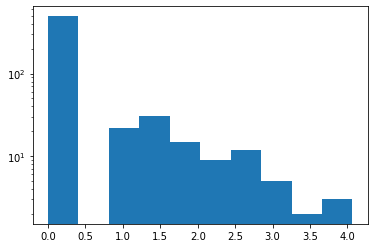

In [127]:
plt.hist(sam_xt.adata.X[:,gi].A)
plt.yscale('log')

In [1595]:
#Plot gene expression

In [128]:
vmin = 1
vmax = 4

In [129]:
subexp = sam_xt.adata[sam_xt.adata.X[:,gi] > vmin]

In [130]:
subexp

View of AnnData object with n_obs × n_vars = 99 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'test', 'named_lc', 'base_leiden_clusters', 'yw_clusters', 'eq_clusters', 'eq_supertype', 'eq_supertype_v2', 'clusters_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [131]:
scalar_mappable = cm.ScalarMappable(cmap='viridis', norm=colors.Normalize(vmin=vmin, vmax=vmax))

In [132]:
organism = 'Xenopus PVH'

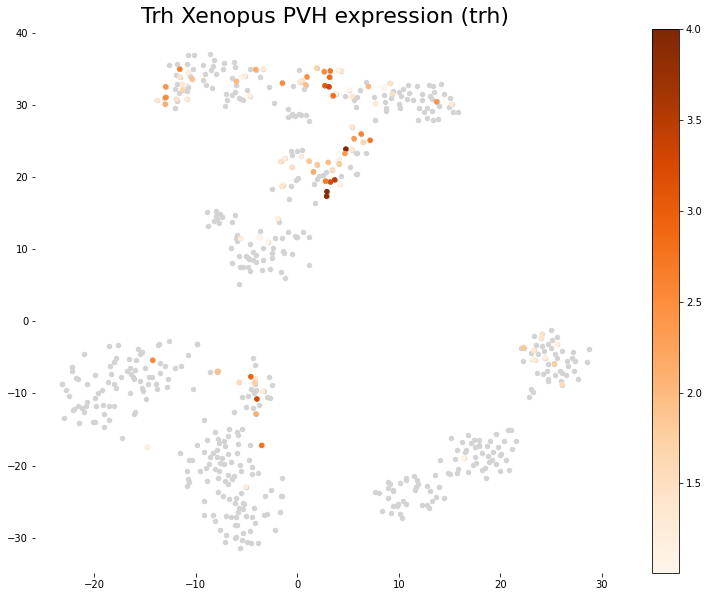

In [133]:
save_figure = False

plt.figure(figsize = (13,10))
plt.scatter(sam_xt.adata.obsm['X_tsne'][:,0],sam_xt.adata.obsm['X_tsne'][:,1], c = 'lightgrey',s=20)
plt.scatter(subexp.obsm['X_tsne'][:,0],subexp.obsm['X_tsne'][:,1], c = subexp.X[:,gi].A,s=20,cmap = 'Oranges', vmax = vmax)
plt.title(common_name + ' ' + organism + ' expression' + ' (' + gn + ')', fontsize = 22)
plt.box(False)
plt.colorbar()
if save_figure:
    plt.savefig('Figures/Figures_05012026/' + organism + '_' + common_name + '_05032026.png', dpi = 300, bbox_inches = 'tight')
    #plt.savefig('Figures/Figures_025/Billie_Data/' + organism + '_' + common_name + '_lowthresh.svg')
    #plt.savefig('Figures/\Figures_1172025/Billie_Data/' + organism + '_' + common_name + '_lowthresh.pdf')

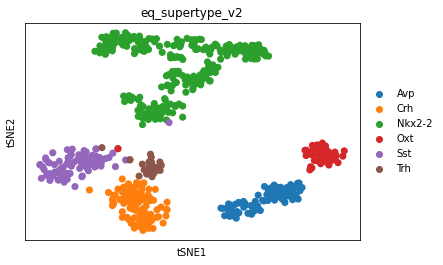

In [134]:
sc.pl.tsne(sam_xt.adata, color = 'eq_supertype_v2')